In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [34]:
def multiple_lineare_regression(X,y,iterations,alpha):
    m = X.shape[0]

    colonne_un = np.ones((m, 1))
    X_b = np.hstack((colonne_un, X))

    n_caracteristiques = X_b.shape[1]
    W = np.zeros((n_caracteristiques, 1))
    losses = []

    for i in range(iterations):
        y_pred = X_b @ W

        erreur = y_pred - y

        gradients = (1/m) * (X_b.T @ erreur)

        losses.append(np.linalg.norm(erreur))

        W -= alpha * gradients

    return W, losses


In [35]:
def normalize(X):
    m_mean = X.mean(axis=0)
    m_std = X.std(axis=0)
    return (X - m_mean) / m_std

In [36]:
data=pd.read_csv("../datasets/server_downtime_dataset_20000.csv")
X = normalize(data[["Downtime_Minutes","Users_Affected","Transactions","Data_Risk_Transactions_Lost"]].values)
Y = normalize(data[["Financial_Loss_INR"]].values)

In [37]:
W, losses = multiple_lineare_regression(X,Y,iterations=2000,alpha=0.01)

[[-1.63102420e-16]
 [ 3.90535651e-01]
 [ 6.90987153e-01]
 [ 2.55677920e-01]
 [ 4.47714197e-03]]


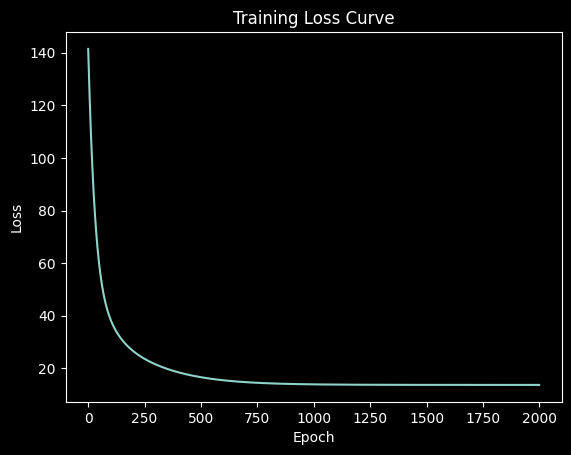

In [38]:
print(W)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()